# Plotting for box model 

In [1]:
# Box model written by Neosha after Brinkerhoff et al. (2016)
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

import importlib


In [2]:
from boxmodel_functions import rhs, solve, make_synthetic_Q_in

In [3]:
plt.rcParams.update({'font.size': 20})

In [25]:
A0_hat = 0.9
P0_hat = 0.1
k_hat  = 0.44 # velocity parameter
r_hat  = 0.02
Pi     = 0.09 #0.44   # was 0.09
Psi    =  0.018 #0.61   # was 0.018
Chi    = 0.2   # 3.41 # was 0.11  
gamma  =  0.4 # 0.4    # was 0.22 #  <--- model stability is sensitive to this! 
alpha  = 5/4   # was 5/4 # closure and opening rates?
beta   = 3/2   # was 3/2

### Case 1: long leadup flood, 200 days

In [40]:
t_start, t_end = 0.0, 200.00
num_timesteps = 1000
t_eval = np.linspace(t_start, t_end, num_timesteps)


# DEFINE FLOOD PARAMS!!! 

'''
# FOR LONG LEADUP:
t_flood=100
flood_magnitude=3.0
flood_width=50
'''

# FOR NORMAL CURVE:
t_flood = 100
flood_magnitude = 3.0
flood_width = 10.0

Q_in_func = make_synthetic_Q_in(t_flood, flood_magnitude, flood_width, "long")

params = dict(
        Q_in_func=Q_in_func,
        k_hat=k_hat, gamma=gamma, psi=Psi, r_hat=r_hat,
        chi=Chi, pi=Pi, alpha=alpha, beta=beta, n=3
    )

initial_conds = [0.9, 0.1] # A0_hat, P0_hat

times, A_hat, P_hat, Q_out, cavitation = solve(
    t_span=(t_start, t_end),
    t_eval = t_eval,
    Q_in_func=Q_in_func,
    ICs = initial_conds,
    params = params)

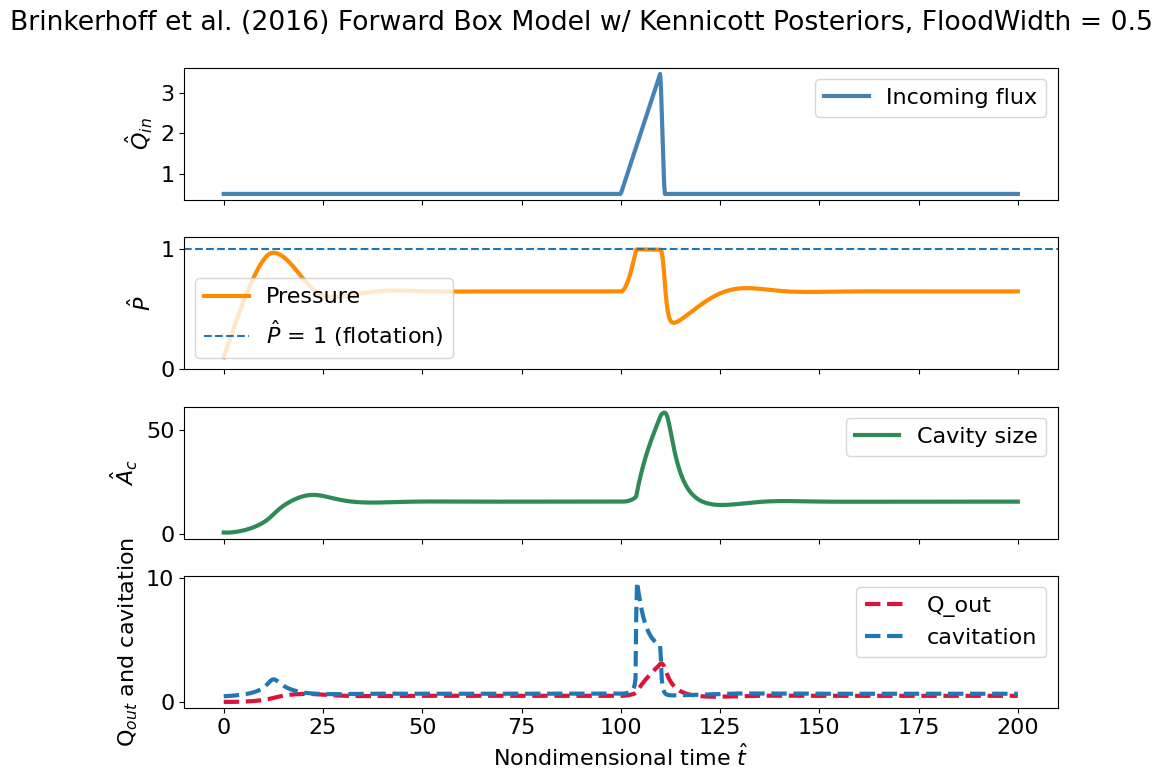

In [32]:
t = times
plt.rcParams.update({'font.size': 16})

Q_in_vals = np.array([Q_in_func(ti) for ti in t])

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t, Q_in_vals, label="Incoming flux", color="steelblue", linewidth=3)
axes[0].set_ylabel("$\\hat{Q}_{in}$")
axes[0].legend();

axes[1].plot(t, P_hat, label="Pressure", color="darkorange", linewidth=3)
axes[1].set_ylabel("$\\hat{P}$")
axes[1].set_ylim(0, 1.1)
#axes[1].set_xlabel("Nondimensional time $\\hat{t}$")
axes[1].axhline(1, label= "$\\hat{P}$ = 1 (flotation)", linestyle='--')
#axes[1].axvline(t_post, label = "$t_{post}$", color = "gray", linestyle="--")
#axes[1].text(0.05, 0.8, "pressure deficit = " + str(P_deficit), transform=axes[1].transAxes)# Places text in the top-left corner
axes[1].legend();

axes[2].plot(t, A_hat, label="Cavity size", color="seagreen", linewidth=3)
axes[2].set_ylabel("$\\hat{A}_c$")
#axes[2].set_xlabel("Nondimensional time $\\hat{t}$")
axes[2].legend(); 

axes[3].plot(t, Q_out, label="Q_out", color="crimson", linestyle="--", linewidth=3)
axes[3].plot(t, cavitation, label = "cavitation", linestyle='--', linewidth=3)
axes[3].set_ylabel("Q$_{out}$ and cavitation")
axes[3].legend();
axes[3].set_xlabel("Nondimensional time $\\hat{t}$")

fig.suptitle("Brinkerhoff et al. (2016) Forward Box Model w/ Kennicott Posteriors, FloodWidth = 0.5")
plt.tight_layout()

## More accurately measure the pressure drop

In [66]:
def calculate_pressure_drop(t, Qin, P_hat, t_flood):
    # t, Qin, and P_hat should all be arrays of the same length
    # t_flood is a single number

    t_flood_index = int(np.floor(t_flood * (num_timesteps/t_end)))
    
    P_before = P_hat[t_flood_index]
    t_before = t_flood
    
    t_after = t[t_flood_index:]
    t_lowestp = t_after[np.argmin(P_hat[t_flood_index:])]
    lowestp = min(P_hat[t_flood_index:])
    
    Pdrop = P_before - lowestp
    return Pdrop


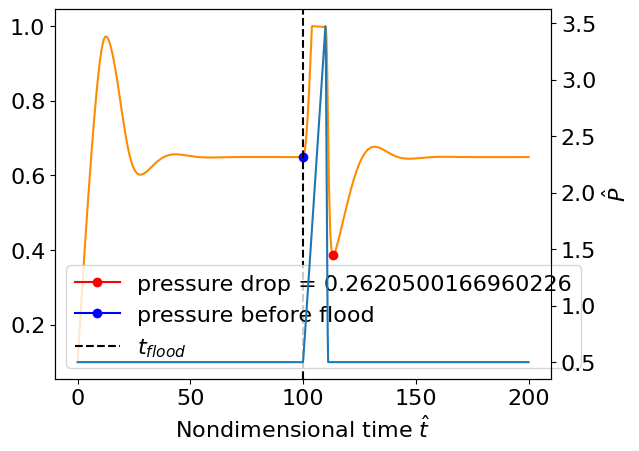

In [65]:
# Test to make sure the pressure drop function is working 
fig, ax1 = plt.subplots()
ax2 = ax1.twinx() 

ax1.plot(t, P_hat, color="darkorange")
ax1.plot(t_lowestp, lowestp, marker='o', color='red', label="pressure drop = " + str(Pdrop))
ax1.plot(t_before, P_before, marker='o', color='blue', label="pressure before flood")
#plt.axvline(times[tafter], linestyle='--')
#plt.axvline(tbefore)
ax1.axvline(t_flood, linestyle='--', color='black', label="$t_{flood}$")
ax1.set_xlabel("Nondimensional time $\\hat{t}$")
ax2.set_ylabel("$\\hat{P}$")


ax2.plot(t, np.array([Q_in_func(ti) for ti in t]))
ax1.legend()